In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Salary_Data.csv to Salary_Data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("Salary_Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.shape

(6704, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [ ]:
# Numerical columns
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Years of Experience"] = df["Years of Experience"].fillna(
    df["Years of Experience"].median()
)

# Categorical columns
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Education Level"] = df["Education Level"].fillna(
    df["Education Level"].mode()[0]
)

df["Job Title"] = df["Job Title"].fillna(
    df["Job Title"].mode()[0]
)

# Target
df = df.dropna(subset=["Salary"])

In [ ]:
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(4911)

In [ ]:
print("Before:", df.shape)

print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("After:", df.shape)
print("Duplicates now:", df.duplicated().sum())

Before: (6699, 6)
Duplicates: 4911
After: (1788, 6)
Duplicates now: 0


In [ ]:
df.shape

(1788, 6)

Boxplot for outliers

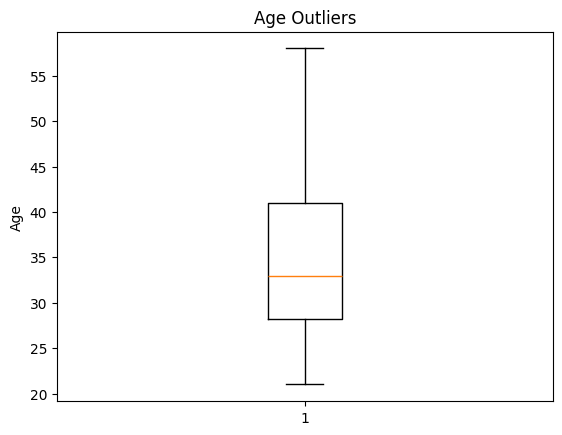

In [ ]:
plt.boxplot(df["Age"])
plt.title("Age Outliers")
plt.ylabel("Age")
plt.show()

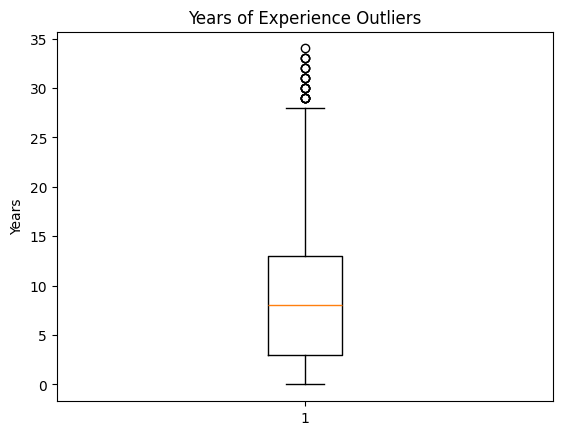

In [ ]:
plt.boxplot(df["Years of Experience"])
plt.title("Years of Experience Outliers")
plt.ylabel("Years")
plt.show()

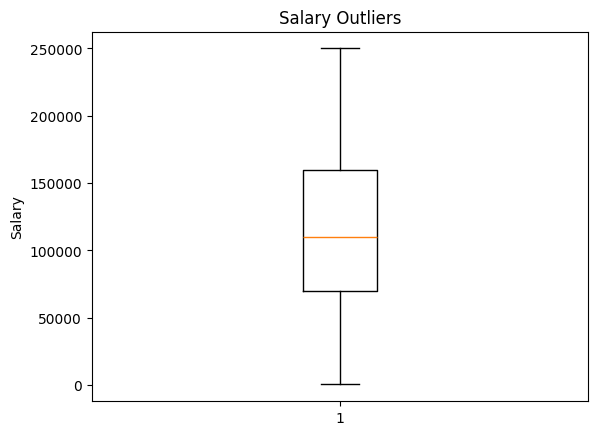

In [ ]:
plt.boxplot(df["Salary"])
plt.title("Salary Outliers")
plt.ylabel("Salary")
plt.show()

outliers in age

In [ ]:
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

print("Age lower:", lower_age)
print("Age upper:", upper_age)

Age lower: 11.0
Age upper: 59.0


In [ ]:
age_outliers = df[
    (df["Age"] < lower_age) |
    (df["Age"] > upper_age)
]

print(age_outliers[["Age", "Years of Experience", "Salary"]])

       Age  Years of Experience    Salary
1211  61.0                 20.0  200000.0
1225  62.0                 19.0  200000.0
1236  62.0                 20.0  200000.0
1260  60.0                 18.0  195000.0
2396  60.0                 33.0  179180.0
2421  60.0                 34.0  188651.0


outliers in years of experience

In [ ]:
Q1_exp = df["Years of Experience"].quantile(0.25)
Q3_exp = df["Years of Experience"].quantile(0.75)

IQR_exp = Q3_exp - Q1_exp

lower_exp = Q1_exp - 1.5 * IQR_exp
upper_exp = Q3_exp + 1.5 * IQR_exp

print("Experience lower:", lower_exp)
print("Experience upper:", upper_exp)

Experience lower: -12.0
Experience upper: 28.0


In [ ]:
exp_outliers = df[
    (df["Years of Experience"] < lower_exp) |
    (df["Years of Experience"] > upper_exp)
]

print(exp_outliers[["Age", "Years of Experience", "Salary"]])

       Age  Years of Experience    Salary
2378  53.0                 31.0  166109.0
2387  57.0                 30.0  121450.0
2396  60.0                 33.0  179180.0
2401  57.0                 33.0  191790.0
2421  60.0                 34.0  188651.0
2435  57.0                 33.0  188232.0
2541  55.0                 30.0  183138.0
2543  54.0                 29.0  191915.0
2554  54.0                 29.0  158254.0
2557  52.0                 29.0  194214.0
2574  54.0                 31.0  193746.0
2600  54.0                 31.0  191818.0
2607  55.0                 30.0  183020.0
2632  56.0                 31.0  197354.0
2643  54.0                 30.0  186321.0
2787  55.0                 29.0  190543.0
2800  54.0                 29.0  158966.0
2803  52.0                 29.0  194778.0
2820  54.0                 32.0  195270.0
2846  54.0                 32.0  191510.0
2871  54.0                 32.0  191267.0
3104  54.0                 30.0  184660.0


Remove them

In [ ]:
df = df[
    (df["Age"] >= lower_age) &
    (df["Age"] <= upper_age) &
    (df["Years of Experience"] >= lower_exp) &
    (df["Years of Experience"] <= upper_exp)
]

In [ ]:
print(df.shape)

(1762, 6)


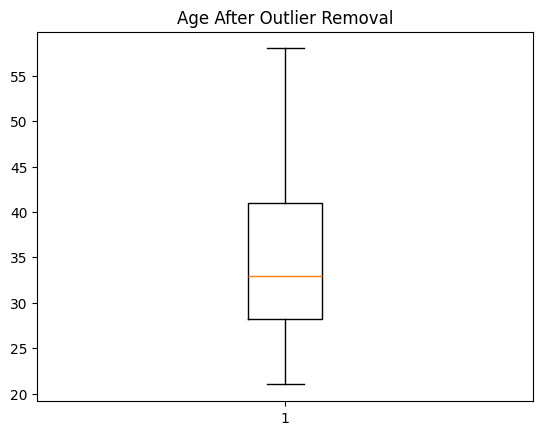

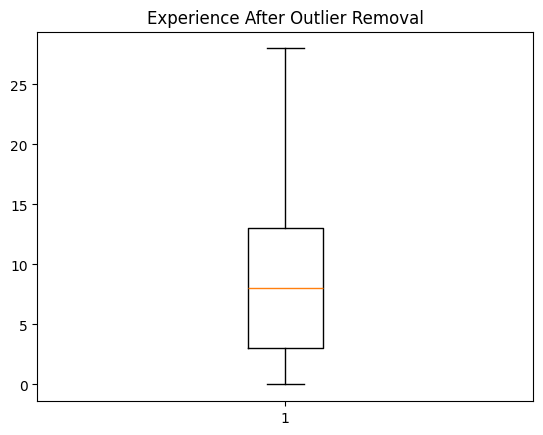

In [ ]:
plt.boxplot(df["Age"])
plt.title("Age After Outlier Removal")
plt.show()

plt.boxplot(df["Years of Experience"])
plt.title("Experience After Outlier Removal")
plt.show()

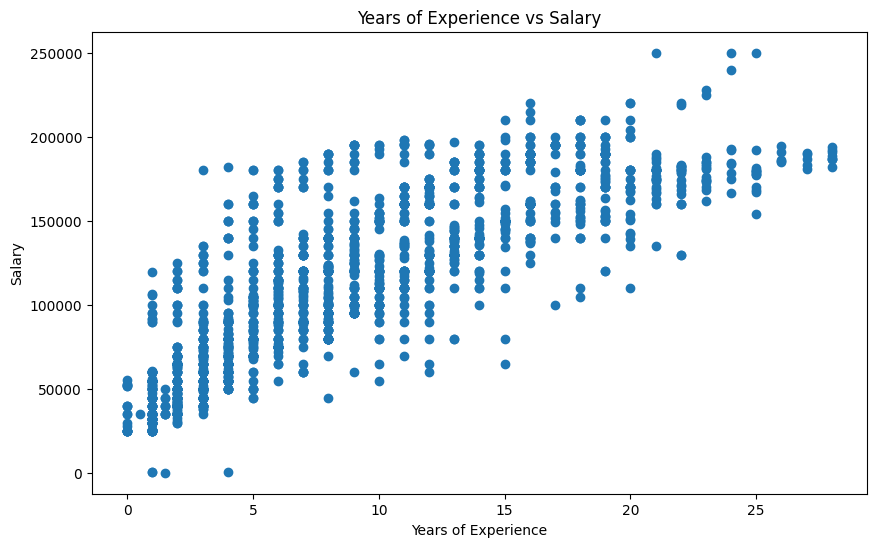

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(df["Years of Experience"], df["Salary"])

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.show()

In [ ]:
correlation=df["Years of Experience"].corr(df["Salary"])
print(correlation)

0.8271760734707893


In [ ]:
corr = df.corr(numeric_only=True)

print(corr)

                          Age  Years of Experience    Salary
Age                  1.000000             0.935973  0.763096
Years of Experience  0.935973             1.000000  0.827176
Salary               0.763096             0.827176  1.000000


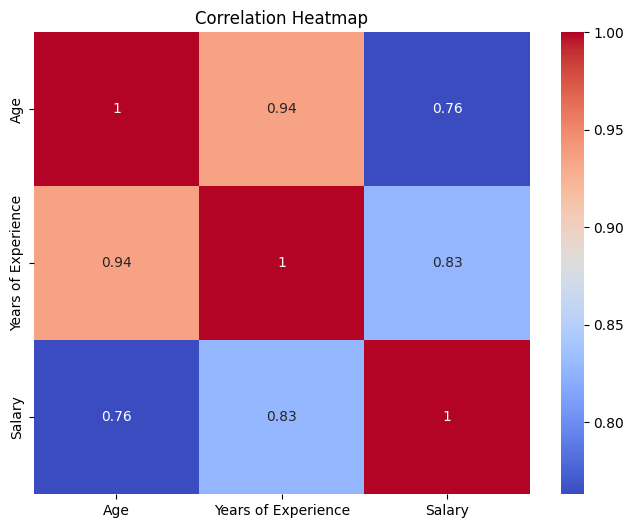

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True, #nnot=True enduku?

#numbers cells lopala display chestundi.
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["Gender", "Education Level", "Job Title"],
    drop_first=True #one category baseline ga automatically remove avutundi.
)

In [ ]:
print(df_encoded.dtypes)

Age                           float64
Years of Experience           float64
Salary                        float64
Gender_Male                      bool
Gender_Other                     bool
                               ...   
Job Title_UX Designer            bool
Job Title_UX Researcher          bool
Job Title_VP of Finance          bool
Job Title_VP of Operations       bool
Job Title_Web Developer          bool
Length: 202, dtype: object


In [ ]:
df_encoded = df_encoded.astype(int)

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["Gender", "Education Level", "Job Title"],
    drop_first=True,
    dtype=int
)

In [ ]:
X=df_encoded.drop("Salary",axis=1)
y=df_encoded["Salary"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns)

print("\nTarget:")
print(y.head())

X shape: (1762, 201)
y shape: (1762,)

X columns:
Index(['Age', 'Years of Experience', 'Gender_Male', 'Gender_Other',
       'Education Level_Bachelor's Degree', 'Education Level_High School',
       'Education Level_Master's', 'Education Level_Master's Degree',
       'Education Level_PhD', 'Education Level_phD',
       ...
       'Job Title_Supply Chain Manager', 'Job Title_Technical Recruiter',
       'Job Title_Technical Support Specialist', 'Job Title_Technical Writer',
       'Job Title_Training Specialist', 'Job Title_UX Designer',
       'Job Title_UX Researcher', 'Job Title_VP of Finance',
       'Job Title_VP of Operations', 'Job Title_Web Developer'],
      dtype='object', length=201)

Target:
0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
"""
random_state=42 enduku?

Train/test split random ga jarugutundi.

random_state=42 petti same split every time reproduce cheyyagalamu.

42 special mathematical value kaadu; reproducibility kosam arbitrary fixed number"""

'\nrandom_state=42 enduku?\n\nTrain/test split random ga jarugutundi.\n\nrandom_state=42 petti same split every time reproduce cheyyagalamu.\n\n42 special mathematical value kaadu; reproducibility kosam arbitrary fixed number'

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1409, 201)
X_test: (353, 201)
y_train: (1409,)
y_test: (353,)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [ ]:
print("Intercept:", model.intercept_)
print("Number of coefficients:", len(model.coef_))

Intercept: 6371.600268933471
Number of coefficients: 201


In [ ]:
print(predictions[:10])

[197544.76508433 174491.57538828 131175.68023999 100986.18413133
  82353.77617424 189835.90195873 112357.57347723 119270.13456026
 133622.77154776  22735.48849861]


In [ ]:
print(y_test.head(10))

2823    177862.0
214     130000.0
970     130000.0
2141    100000.0
6603     70000.0
2429    154207.0
3433    115000.0
396     120000.0
3122    135378.0
6294     35000.0
Name: Salary, dtype: float64


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 14482.832574670656
MSE : 384557364.27104133
RMSE: 19610.13422368754
R²  : 0.8555481192360141


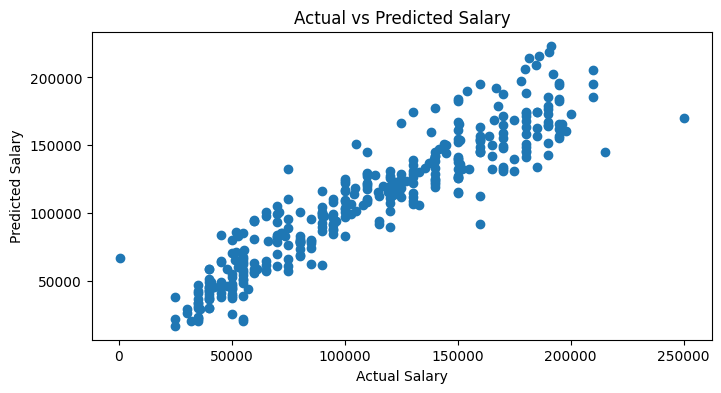

In [ ]:
plt.figure(figsize=(8, 4))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

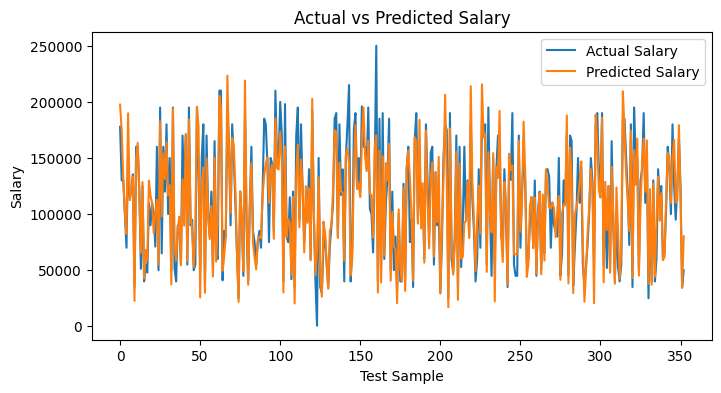

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(y_test.values, label="Actual Salary")
plt.plot(predictions, label="Predicted Salary")

plt.xlabel("Test Sample")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()

plt.show()

In [ ]:
print("=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MODEL EVALUATION
MAE  : 14482.83
MSE  : 384557364.27
RMSE : 19610.13
R²   : 0.8555
